<a href="https://colab.research.google.com/github/Kaashish1111/machineLearningAlgorithms/blob/main/kMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

X = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [8, 8],
    [9, 8],
    [10, 9]
])

In [2]:
K = 2

centroids = X[[0, 3]].astype(float)

print(centroids)

[[1. 1.]
 [8. 8.]]


In [3]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

In [4]:
def assign_clusters(X, centroids):
    clusters = []

    for point in X:
        distances = []

        for centroid in centroids:
            dist = euclidean_distance(point, centroid)
            distances.append(dist)

        cluster = np.argmin(distances)
        clusters.append(cluster)

    return np.array(clusters)

In [5]:
labels = assign_clusters(X, centroids)

print(labels)

[0 0 0 1 1 1]


In [6]:
def update_centroids(X, labels, centroids, K):
    new_centroids = []

    for i in range(K):
        cluster_points = X[labels == i]

        if len(cluster_points) > 0:
            centroid = np.mean(cluster_points, axis=0)
        else:
            centroid = centroids[i]

        new_centroids.append(centroid)

    return np.array(new_centroids)

In [7]:
new_centroids = update_centroids(
    X, labels, centroids, K
)

print(new_centroids)

[[2.         1.33333333]
 [9.         8.33333333]]


In [8]:
def kmeans(X, K, max_iters=100, tol=1e-4, random_state=42):

    # Step 1: Initialize centroids
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=K, replace=False)
    centroids = X[indices].astype(float)

    prev_labels = None

    # Step 2: Iterate
    for iteration in range(max_iters):

        # Assign points to nearest centroid
        labels = assign_clusters(X, centroids)

        # Update centroids
        new_centroids = update_centroids(
            X, labels, centroids, K
        )

        # Calculate centroid movement
        movement = np.linalg.norm(
            new_centroids - centroids
        )

        print(f"Iteration {iteration + 1}")
        print("Centroids:", new_centroids)

        # Check convergence
        if (prev_labels is not None and
            np.array_equal(labels, prev_labels)):
            centroids = new_centroids
            print("Converged!")
            break

        if movement <= tol:
            centroids = new_centroids
            print("Converged!")
            break

        # Prepare for next iteration
        centroids = new_centroids
        prev_labels = labels.copy()

    return labels, centroids

In [9]:
labels, centroids = kmeans(X, K=2)

print("Final labels:", labels)
print("Final centroids:", centroids)

Iteration 1
Centroids: [[2.         1.33333333]
 [9.         8.33333333]]
Iteration 2
Centroids: [[2.         1.33333333]
 [9.         8.33333333]]
Converged!
Final labels: [0 0 0 1 1 1]
Final centroids: [[2.         1.33333333]
 [9.         8.33333333]]


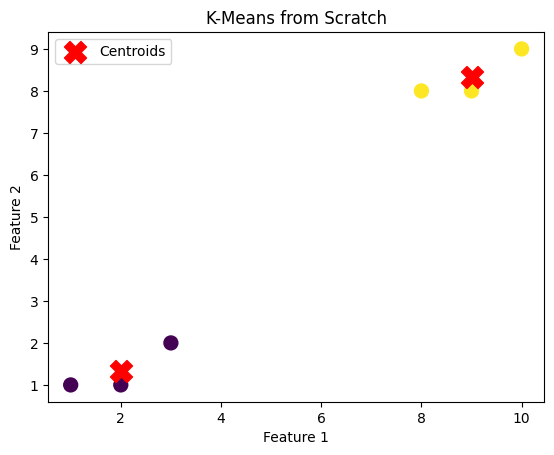

In [10]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=100
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means from Scratch")
plt.legend()
plt.show()